In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**LOADING DATASET + LABEL**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/RFMiD_Training_Labels.csv")
image_paths = "/content/drive/MyDrive/Dataset/Training_Set/Training/" + df["ID"].astype(str) + ".png"

val_df= pd.read_csv("/content/drive/MyDrive/Dataset/RFMiD_Validation_Labels.csv")
val_paths = "/content/drive/MyDrive/Dataset/Validation/" + val_df["ID"].astype(str) + ".png"

test_df = pd.read_csv("/content/drive/MyDrive/Dataset1/RFMiD_Testing_Labels.csv")
test_paths = "/content/drive/MyDrive/Dataset1/Test/" + test_df["ID"].astype(str) + ".png"

labels = df["Disease_Risk"].to_numpy()
val_labels = val_df["Disease_Risk"].to_numpy()
test_labels = test_df["Disease_Risk"].to_numpy()

data = tf.data.Dataset.from_tensor_slices((image_paths, labels))
val = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = image/255.0
    return image, label

data = data.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val = val.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test = test.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

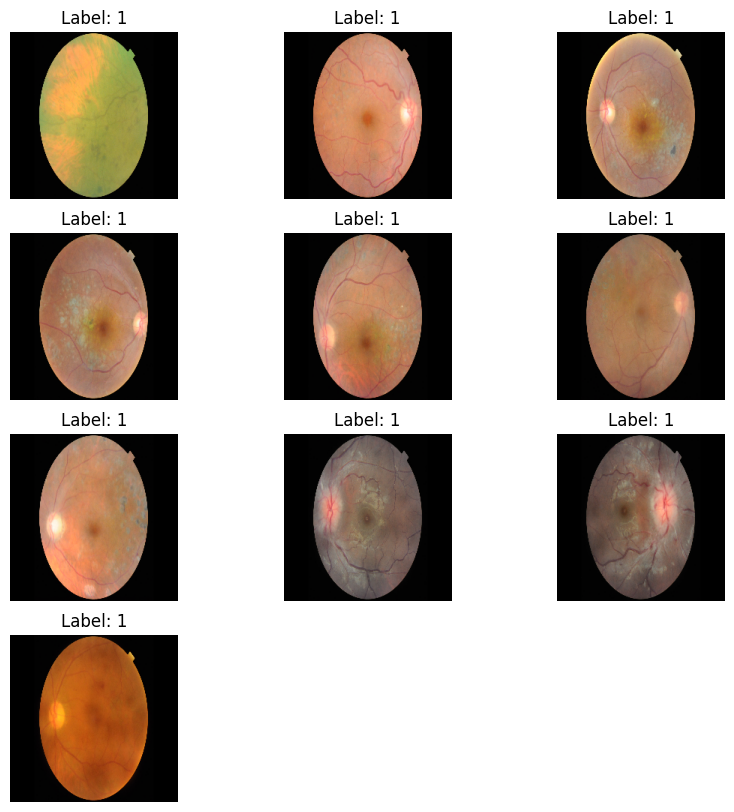

In [ ]:
img, label = next(iter(val))

plt.figure(figsize=(10,10))

for i in range(10):
    plt.subplot(4, 3, i + 1)
    plt.imshow((img[i].numpy()*255).astype("uint8"))
    plt.title(f"Label: {label[i].numpy()}")
    plt.axis("off")

plt.show()

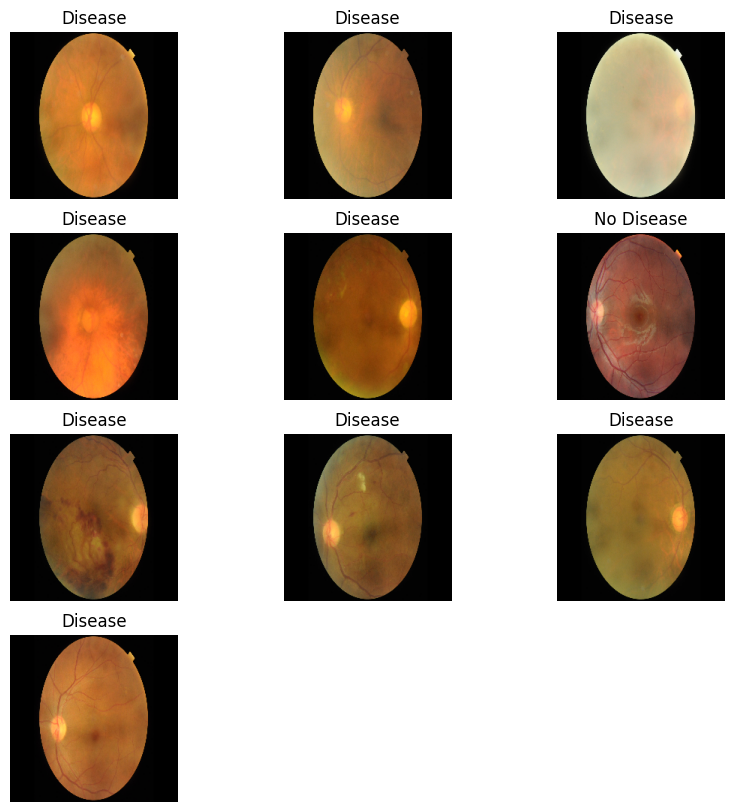

In [ ]:
images, labels = next(iter(data))

plt.figure(figsize=(10,10))

for i in range(10):
    plt.subplot(4, 3, i + 1)
    plt.imshow((images[i].numpy()*255).astype("uint8"))

    label = labels[i].numpy()
    text = "No Disease" if label == 0 else "Disease"

    plt.title(text)
    plt.axis("off")
plt.show()

In [ ]:
for batch in data.take(1):
    print("Train batch OK")

for batch in val.take(1):
    print("Val batch OK")

Train batch OK
Val batch OK


**CUSTOM CNN TO TRAIN THE MODEL**

In [ ]:
def build_custom_cnn():
    model = models.Sequential()
    model.add(layers.Input(shape=(224, 224, 3)))

    #Base Model (Convolutional Layer)
    model.add(layers.Conv2D(32, (3,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(64, (3,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(128, (3,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))


    # Dense Layer (Fully Connected Layer)
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model


model = build_custom_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()])

#history = model.fit(data,epochs=15,validation_data=val)

**Loss and Accuracy**

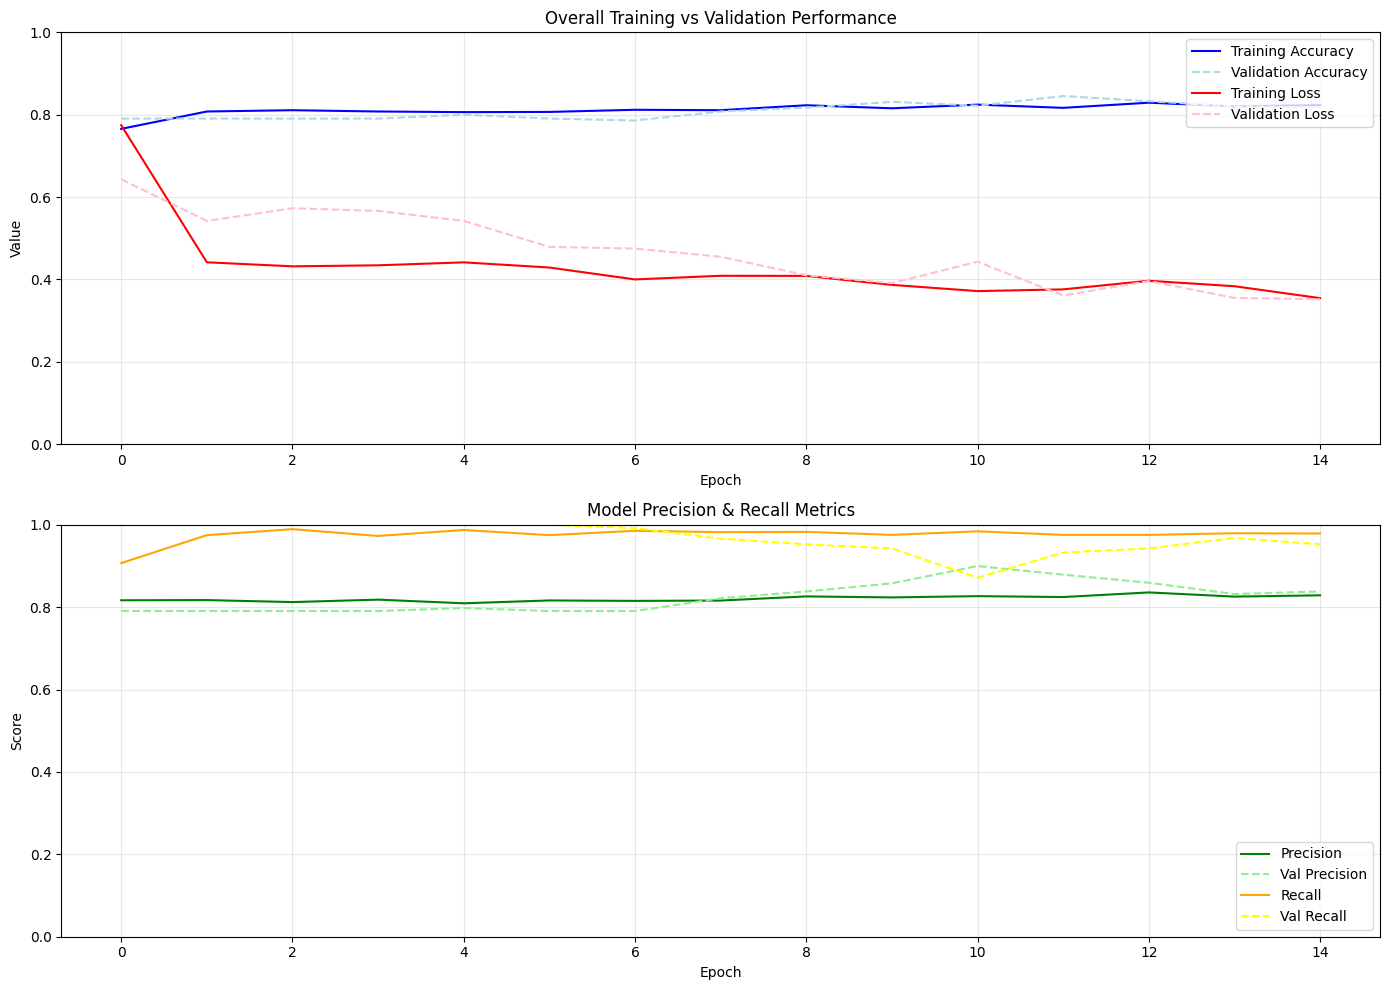

In [ ]:
plt.figure(figsize=(14, 10))

# 1. Accuracy and Loss (Your original requested plot)
plt.subplot(2, 1, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='lightblue', linestyle='--')
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='pink', linestyle='--')
plt.title("Overall Training vs Validation Performance")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.ylim([0, 1])
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 2. Precision and Recall (The new requested plot)
plt.subplot(2, 1, 2)
plt.plot(history.history['precision'], label='Precision', color='green')
plt.plot(history.history['val_precision'], label='Val Precision', color='lightgreen', linestyle='--')
plt.plot(history.history['recall'], label='Recall', color='orange')
plt.plot(history.history['val_recall'], label='Val Recall', color='yellow', linestyle='--')
plt.title("Model Precision & Recall Metrics")
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

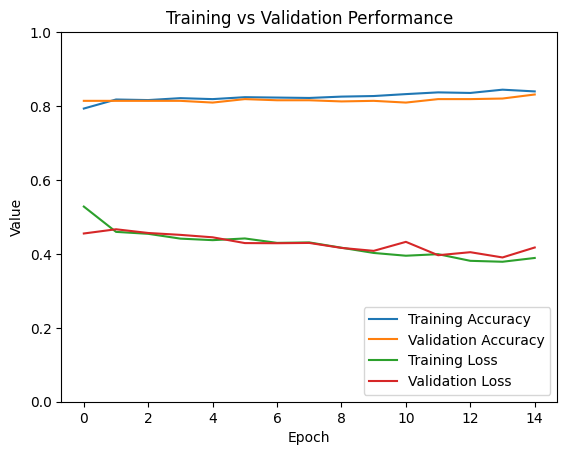

In [ ]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title("Training vs Validation Performance")

plt.show()

#Evaluation

In [ ]:
test_loss, test_acc, test_recall, test_precision = model.evaluate(test)

print("Test Accuracy:", test_acc)
print("Test loss:",test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 217s 11s/step - accuracy: 0.2844 - loss: 0.6973 - precision: 0.8077 - recall: 0.1245
Test Accuracy: 0.28437501192092896
Test loss: 0.6972926259040833


#Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test)

# Convert probabilities → 0/1
y_pred = (y_pred > 0.3).astype(int).flatten()
y_true = test_labels

print(confusion_matrix(y_true, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step
[[  1 133]
 [  1 505]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 966ms/step


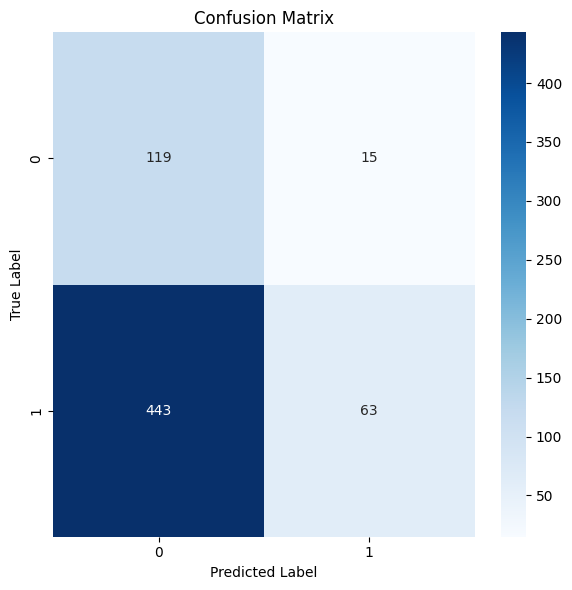

In [ ]:
y_true = []
y_pred = []

for images, labels in test:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#Classification

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.21      0.89      0.34       134
           1       0.81      0.12      0.22       506

    accuracy                           0.28       640
   macro avg       0.51      0.51      0.28       640
weighted avg       0.68      0.28      0.24       640



#Calculation

In [ ]:
cm=confusion_matrix(y_true, y_pred)
# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# etrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print Results
print("\nModel Performance:\n")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1_score:.4f}")


Model Performance:

Accuracy     : 0.2844
Precision    : 0.8077
Recall       : 0.1245
Specificity  : 0.8881
F1 Score     : 0.2158


In [ ]:
import numpy as np

# Given confusion matrix

cm = np.array([[1, 133],
              [1, 505]])

# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# Metrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print Results
print("\nModel Performance:\n")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1_score:.4f}")


Model Performance:

Accuracy     : 0.7906
Precision    : 0.7915
Recall       : 0.9980
Specificity  : 0.0075
F1 Score     : 0.8829
